# Customer Segmentation 🛍️
In this project, we aim to segment mall customers based on their purchasing behavior. We will implement, visualize, and compare three clustering algorithms: K-Means, Hierarchical Clustering, and DBSCAN.

## 📦 Importing Libraries and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import joblib

# Set dark theme for plots
# plt.style.use('dark_background')
# sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "grid.color": "#333333"})

# Load the dataset
df = pd.read_csv('Customer.csv')
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 🧹 Data Preprocessing
We drop `CustomerID` because it provides no analytical value. To achieve clear behavioral segments, we will focus on `Annual Income` and `Spending Score`. We then apply `StandardScaler` to ensure all features contribute equally to the distance metrics.

In [2]:
# Select primary features for behavioral segmentation
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🧩 K-Means Clustering
First, we use the Elbow Method and Silhouette Scores to determine the optimal number of clusters (K).

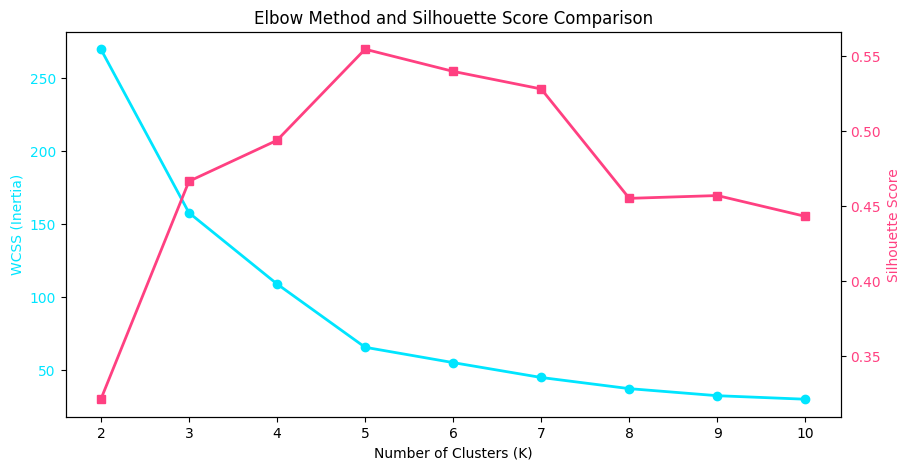

In [3]:
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#00e5ff'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(k_range, wcss, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#ff4081'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_scores, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Score Comparison')
plt.show()

Based on the metrics above, **K=5** yields the highest Silhouette score and a distinct elbow. We will now fit the final K-Means model with 5 clusters.

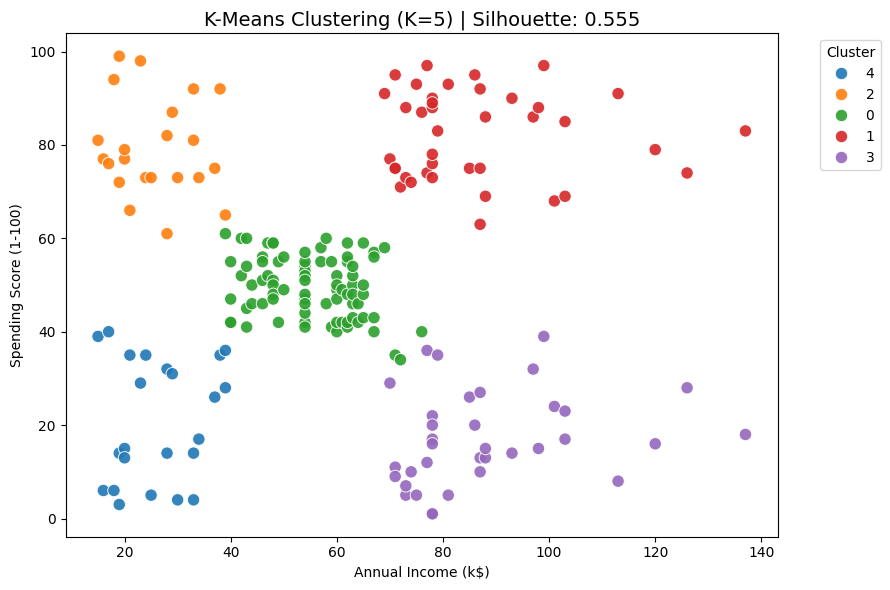

In [6]:
# Final K-Means Model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X['Annual Income (k$)'], y=X['Spending Score (1-100)'], hue=kmeans_labels.astype(str), palette='tab10', s=80, alpha=0.9)

plt.title(f'K-Means Clustering (K=5) | Silhouette: {kmeans_sil:.3f}', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 🪜 Hierarchical Clustering (Agglomerative)
We use a Dendrogram to visualize the hierarchical merging process, then apply Agglomerative Clustering using the Ward linkage method.

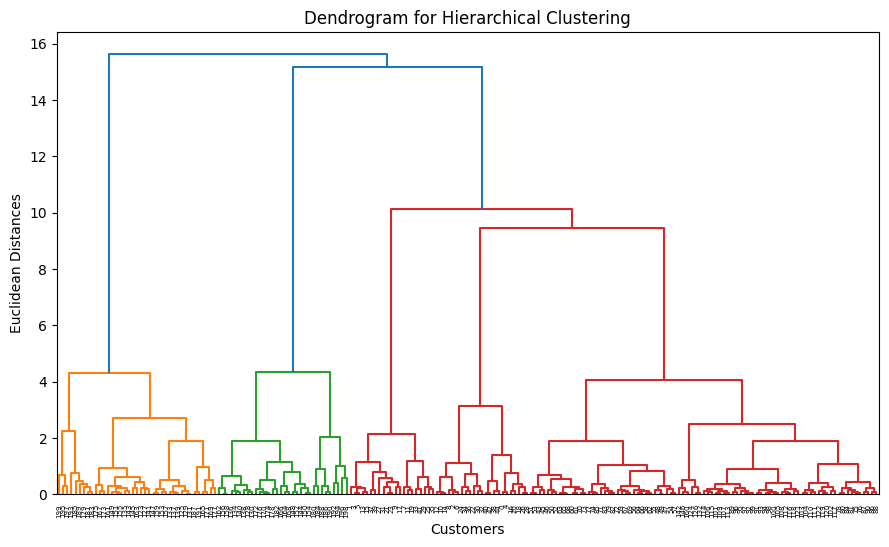

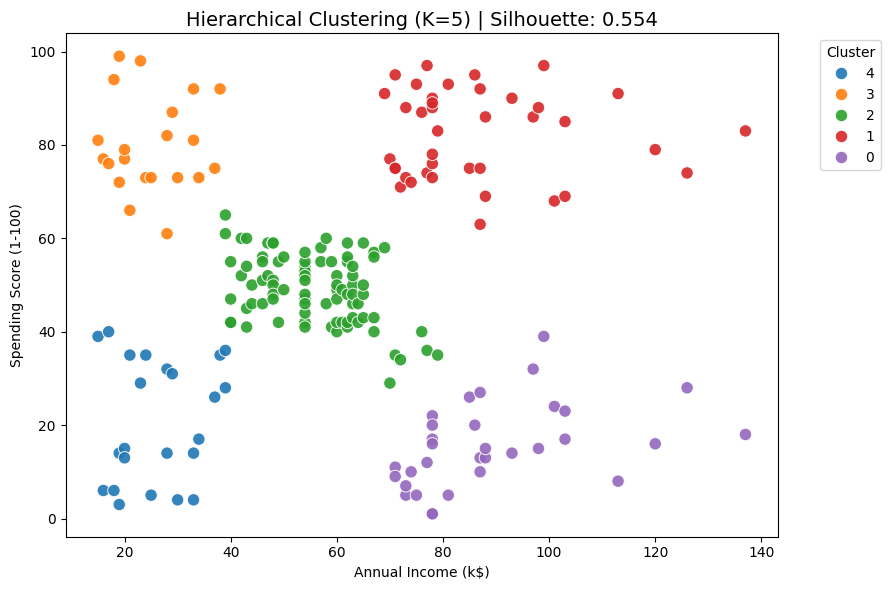

In [7]:
plt.figure(figsize=(10.6,6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

# Final Hierarchical model
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
hc_sil = silhouette_score(X_scaled, hc_labels)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X['Annual Income (k$)'], y=X['Spending Score (1-100)'], hue=hc_labels.astype(str), palette='tab10', s=80, alpha=0.9)
plt.title(f'Hierarchical Clustering (K=5) | Silhouette: {hc_sil:.3f}', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 🧊 DBSCAN Clustering
DBSCAN groups dense regions and isolates outliers as noise (labeled as -1). We tune `eps` and `min_samples` for optimal density mapping.

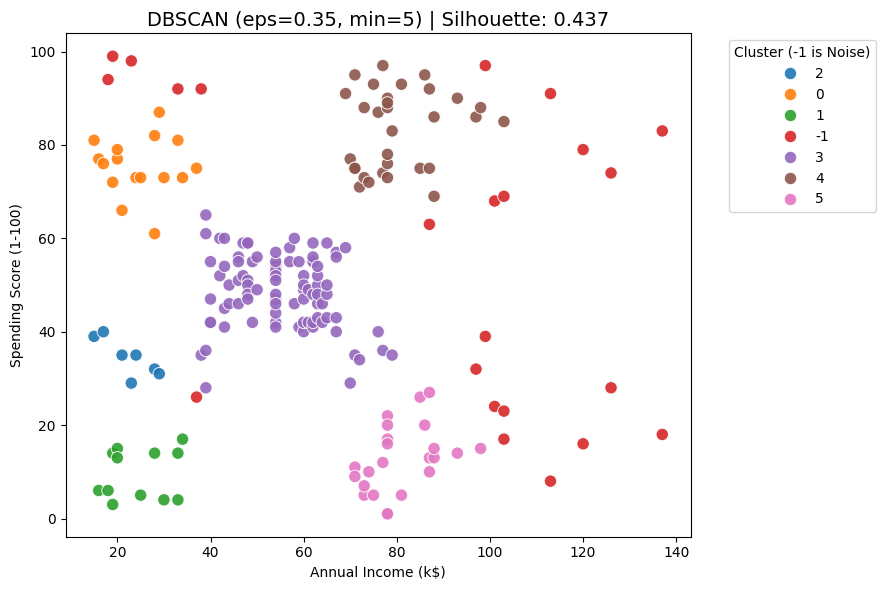

In [8]:
# Final DBSCAN model 
dbscan = DBSCAN(eps=0.35, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# Calculate silhouette only for actual clusters (ignoring noise)
if len(set(db_labels)) > 1:
    db_sil = silhouette_score(X_scaled, db_labels)
else:
    db_sil = -1

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X['Annual Income (k$)'], y=X['Spending Score (1-100)'], hue=db_labels.astype(str), s=80, alpha=0.9)
plt.title(f'DBSCAN (eps=0.35, min=5) | Silhouette: {db_sil:.3f}', fontsize=14)
plt.legend(title='Cluster (-1 is Noise)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 💾 Comparison and Model Export
We compare the performance of all three algorithms, plot it, and export the highest performing model alongside the scaler for future API/production use.

--- Model Evaluation (Silhouette Scores) ---
K-Means:        0.5547
Hierarchical:   0.5538
DBSCAN:         0.4368



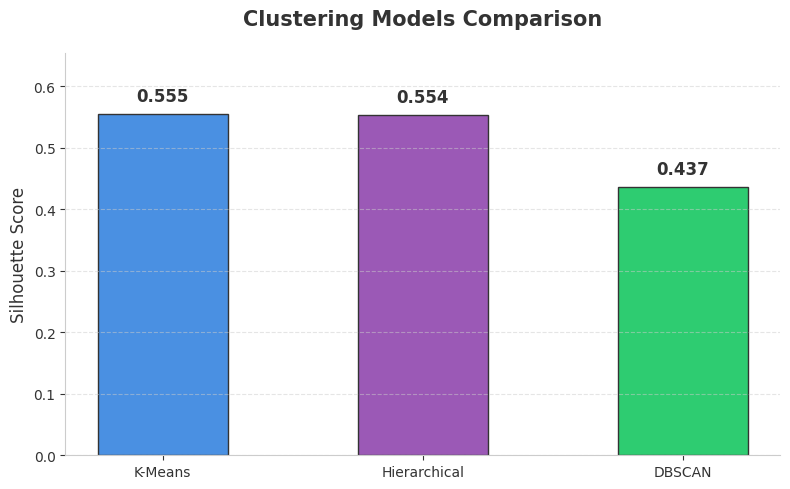


K-Means is the best performing model. Exporting...
Model and Scaler successfully saved to disk ✅



In [15]:
print("--- Model Evaluation (Silhouette Scores) ---")
print(f'K-Means:        {kmeans_sil:.4f}')
print(f'Hierarchical:   {hc_sil:.4f}')
print(f'DBSCAN:         {db_sil:.4f}\n')

# Comparison Visualization

# Data
model_names = ['K-Means', 'Hierarchical', 'DBSCAN']
scores = [kmeans_sil, hc_sil, db_sil]

# Colors
colors = ['#4A90E2', '#9B59B6', '#2ECC71']

# Figure with white background
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.bar(model_names, scores, color=colors, width=0.5, edgecolor='#333333', linewidth=1)

# Add the silhouette score on top of each bar
for bar in bars:
    yval = bar.get_height()
    # Adjust position dynamically
    offset = 0.015 if yval >= 0 else -0.04
    va_alignment = 'bottom' if yval >= 0 else 'top'
    
    ax.text(bar.get_x() + bar.get_width()/2, yval + offset, 
            f'{yval:.3f}', ha='center', va=va_alignment, 
            color='#333333', fontsize=12, fontweight='bold')

# Styling the plot
ax.set_ylabel('Silhouette Score', fontsize=12, color='#333333')
ax.set_title('Clustering Models Comparison', color='#333333', fontsize=15, pad=20, fontweight='bold')

# Dynamic Y-axis limit
ax.set_ylim(min(0, min(scores) - 0.1), max(scores) + 0.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(colors='#333333')

# Horizontal grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

plt.tight_layout()
plt.show()

# Exporting the best model
if kmeans_sil >= max(hc_sil, db_sil):
    print("\nK-Means is the best performing model. Exporting...")
    joblib.dump(kmeans, 'kmeans_segmentation_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    print("Model and Scaler successfully saved to disk ✅\n")

---

*This is my very first Unsupervised-learning project :)*

\- [Tony White](https://github.com/itstonywhite) ✍️